# Week 6 — Paper B Replication: CNN-Transformer + MC Dropout Uncertainty

**Paper:** *Uncertainty Quantification and Remaining Useful Life Prediction Using Deep Learning* (IJSIMM 2025)

**Key Ideas:**
- CNN-Transformer backbone for temporal feature learning
- Monte Carlo Dropout for epistemic uncertainty quantification

**Evaluation:**
- Point metrics (MAE, RMSE, NASA Score)
- Uncertainty sanity checks: do harder cases have higher uncertainty?

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '../src')
from data_loader import load_train, load_test
from preprocess import preprocess_pipeline, INFORMATIVE_SENSORS_FD001
from models.cnn_transformer import CNNTransformerModel
from train import train_model, compute_metrics

plt.style.use('seaborn-v0_8-whitegrid')
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [11]:
# Load and preprocess
df_train = load_train(fd_number=1, rul_cap=125)
df_test, rul_true = load_test(fd_number=1)

WINDOW = 30
data = preprocess_pipeline(df_train, df_test, window_size=WINDOW, rul_cap=125)
print(f'X_train: {data["X_train"].shape}, X_test: {data["X_test"].shape}')

X_train: (14241, 30, 14), X_test: (100, 30, 14)


## 1. CNN-Transformer Model

In [12]:
# Create model
n_features = data['config']['n_features']

model = CNNTransformerModel(
    n_features=n_features,
    seq_len=WINDOW,
    cnn_channels=64,
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=128,
    dropout=0.2,
    mc_dropout=0.1,
)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Parameters: 84,417
CNNTransformerModel(
  (cnn): Sequential(
    (0): Conv1d(14, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, ele

In [13]:
# DataLoaders
BATCH_SIZE = 256
train_ds = TensorDataset(torch.tensor(data['X_train']), torch.tensor(data['y_train']))
val_ds = TensorDataset(torch.tensor(data['X_val']), torch.tensor(data['y_val']))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Train
result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=60,
    lr=1e-3,
    patience=15,
    save_dir='../checkpoints',
    model_name='cnn_transformer_FD001',
    device=device,
)

Training on: mps
Epoch   1/60 | Train Loss: 7612.1610 | Val Loss: 6566.0044 | Val MAE: 70.91 | Val RMSE: 81.78
Epoch   5/60 | Train Loss: 364.9775 | Val Loss: 157.2031 | Val MAE: 9.07 | Val RMSE: 12.66
Epoch  10/60 | Train Loss: 207.4795 | Val Loss: 193.2836 | Val MAE: 8.72 | Val RMSE: 13.93
Epoch  15/60 | Train Loss: 159.5987 | Val Loss: 204.1457 | Val MAE: 10.19 | Val RMSE: 14.31
Epoch  20/60 | Train Loss: 135.8657 | Val Loss: 201.6317 | Val MAE: 10.01 | Val RMSE: 14.23
Early stopping at epoch 20


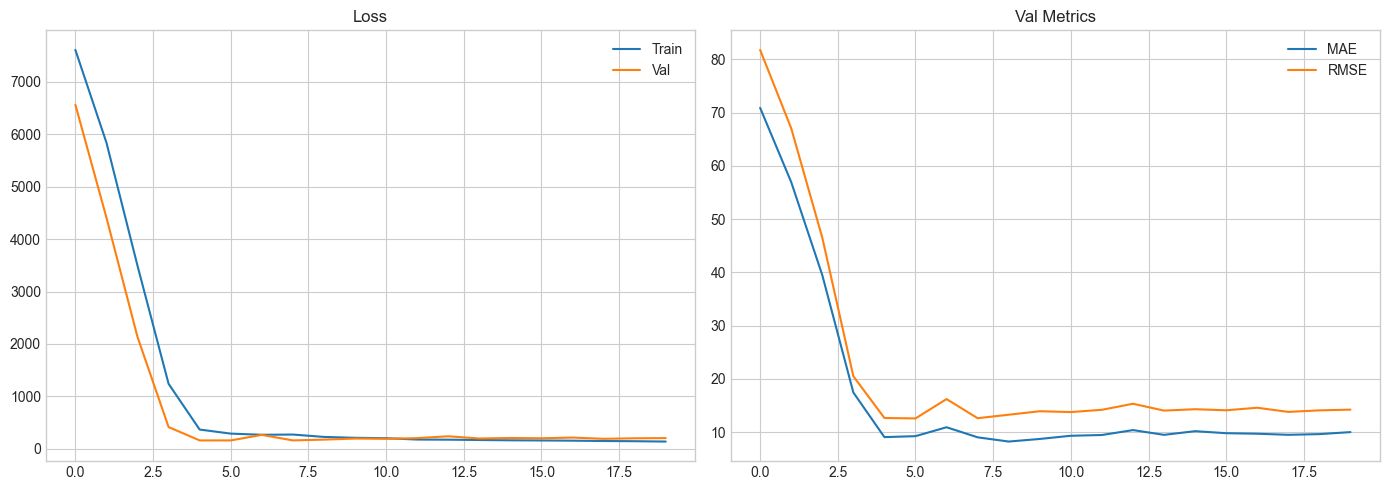

In [14]:
# Training curves
h = result['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['train_loss'], label='Train'); axes[0].plot(h['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(h['val_mae'], label='MAE'); axes[1].plot(h['val_rmse'], label='RMSE')
axes[1].set_title('Val Metrics'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. Monte Carlo Dropout Inference

In [15]:
# MC Dropout prediction
trained_model = result['model']
X_test_t = torch.tensor(data['X_test'], dtype=torch.float32).to(result['device'])

MC_SAMPLES = 100
mean_pred, std_pred, all_preds = trained_model.predict_with_uncertainty(
    X_test_t, n_samples=MC_SAMPLES
)

print(f'Mean predictions range: [{mean_pred.min():.1f}, {mean_pred.max():.1f}]')
print(f'Std (uncertainty) range: [{std_pred.min():.1f}, {std_pred.max():.1f}]')

# Point metrics on MC mean
metrics = compute_metrics(rul_true, mean_pred)
print(f'\nCNN-Transformer (MC mean) Test Results:')
print(f'  MAE: {metrics["MAE"]:.2f}, RMSE: {metrics["RMSE"]:.2f}, NASA: {metrics["NASA_Score"]:.0f}')

Mean predictions range: [2.5, 118.8]
Std (uncertainty) range: [2.6, 15.3]

CNN-Transformer (MC mean) Test Results:
  MAE: 10.48, RMSE: 14.64, NASA: 300


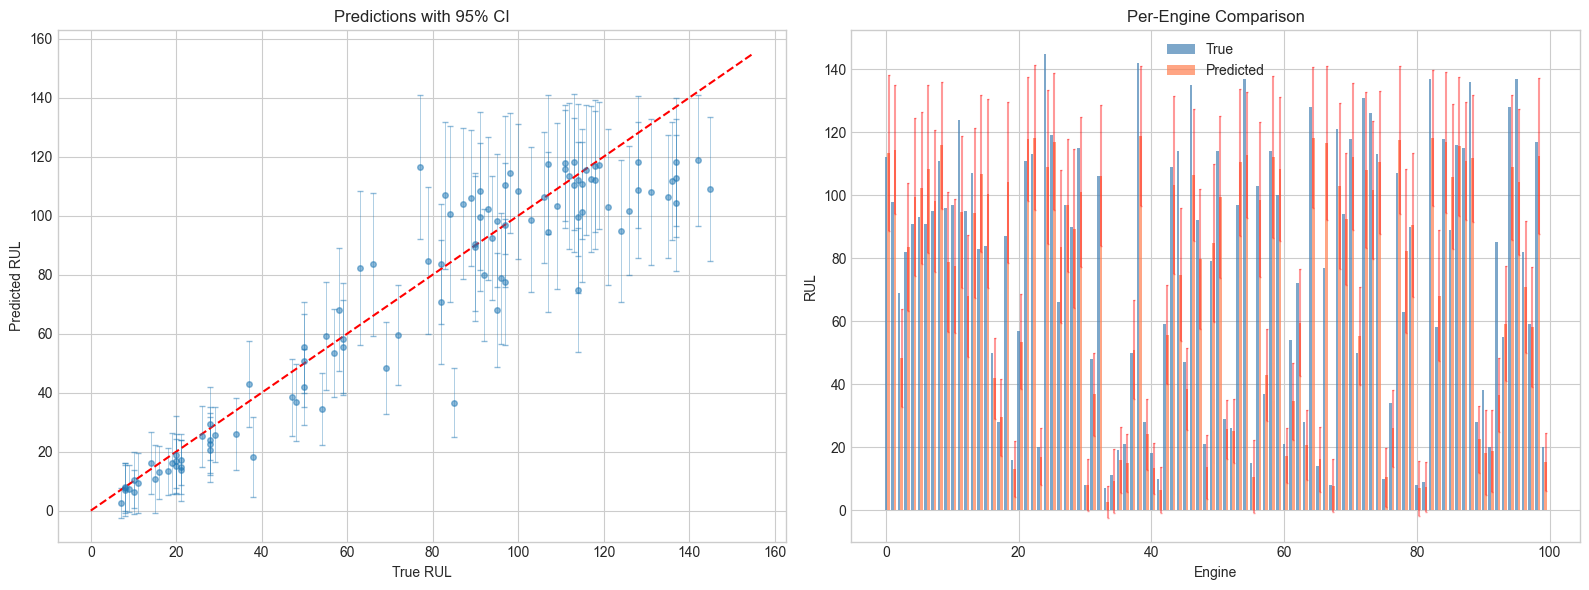

In [16]:
# Visualize predictions with uncertainty bands
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter with error bars
ax = axes[0]
ax.errorbar(rul_true, mean_pred, yerr=1.96*std_pred, fmt='o', alpha=0.5,
             capsize=2, markersize=4, elinewidth=0.5)
lims = [0, max(rul_true.max(), mean_pred.max()) + 10]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
ax.set_title('Predictions with 95% CI')

# Per-engine bar chart
ax = axes[1]
x = np.arange(len(rul_true))
ax.bar(x, rul_true, width=0.4, label='True', alpha=0.7, color='steelblue')
ax.bar(x+0.4, mean_pred, width=0.4, label='Predicted', alpha=0.7, color='coral')
ax.errorbar(x+0.4, mean_pred, yerr=1.96*std_pred, fmt='none', ecolor='red', capsize=1, alpha=0.4)
ax.set_xlabel('Engine'); ax.set_ylabel('RUL'); ax.set_title('Per-Engine Comparison')
ax.legend()

plt.tight_layout(); plt.show()

## 3. Uncertainty Sanity Checks

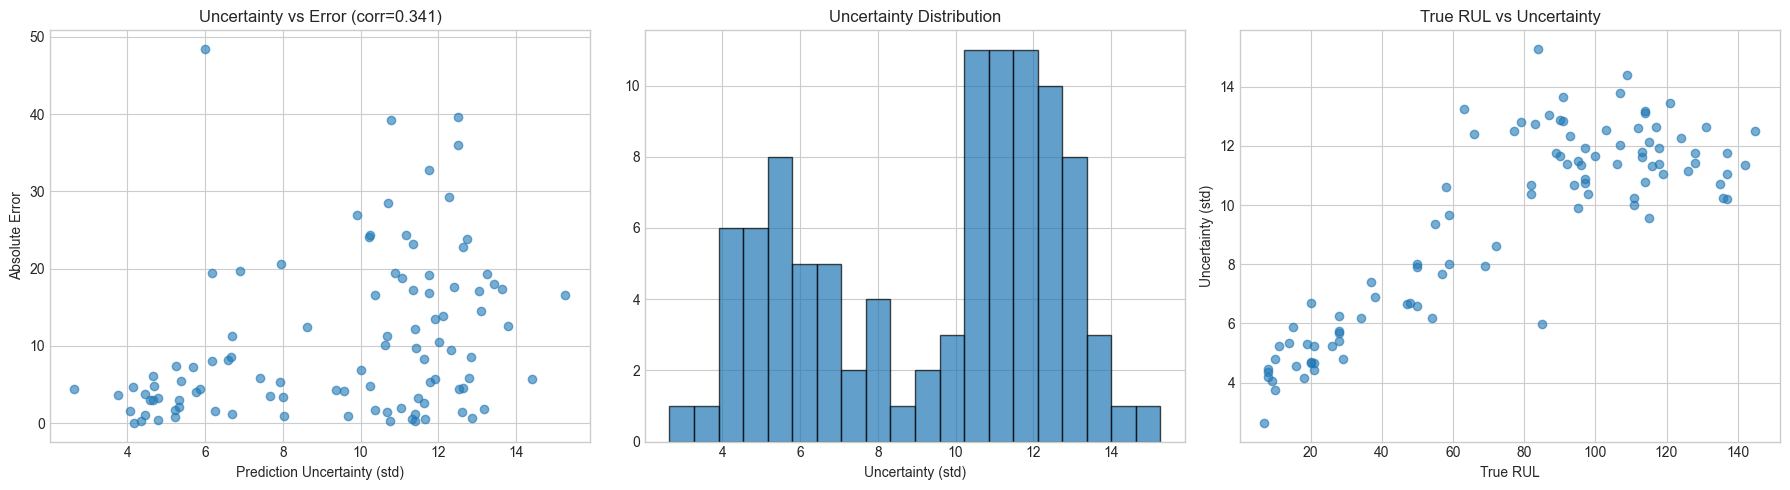

Uncertainty-Error correlation: 0.341
Positive correlation = model is more uncertain when it makes bigger errors (good!)


In [17]:
# Do harder cases have higher uncertainty?
abs_errors = np.abs(mean_pred - rul_true)
corr = np.corrcoef(std_pred, abs_errors)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Uncertainty vs error
axes[0].scatter(std_pred, abs_errors, alpha=0.6)
axes[0].set_xlabel('Prediction Uncertainty (std)')
axes[0].set_ylabel('Absolute Error')
axes[0].set_title(f'Uncertainty vs Error (corr={corr:.3f})')

# Uncertainty distribution
axes[1].hist(std_pred, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Uncertainty (std)')
axes[1].set_title('Uncertainty Distribution')

# Uncertainty vs true RUL
axes[2].scatter(rul_true, std_pred, alpha=0.6)
axes[2].set_xlabel('True RUL')
axes[2].set_ylabel('Uncertainty (std)')
axes[2].set_title('True RUL vs Uncertainty')

plt.tight_layout(); plt.show()

print(f'Uncertainty-Error correlation: {corr:.3f}')
print('Positive correlation = model is more uncertain when it makes bigger errors (good!)')

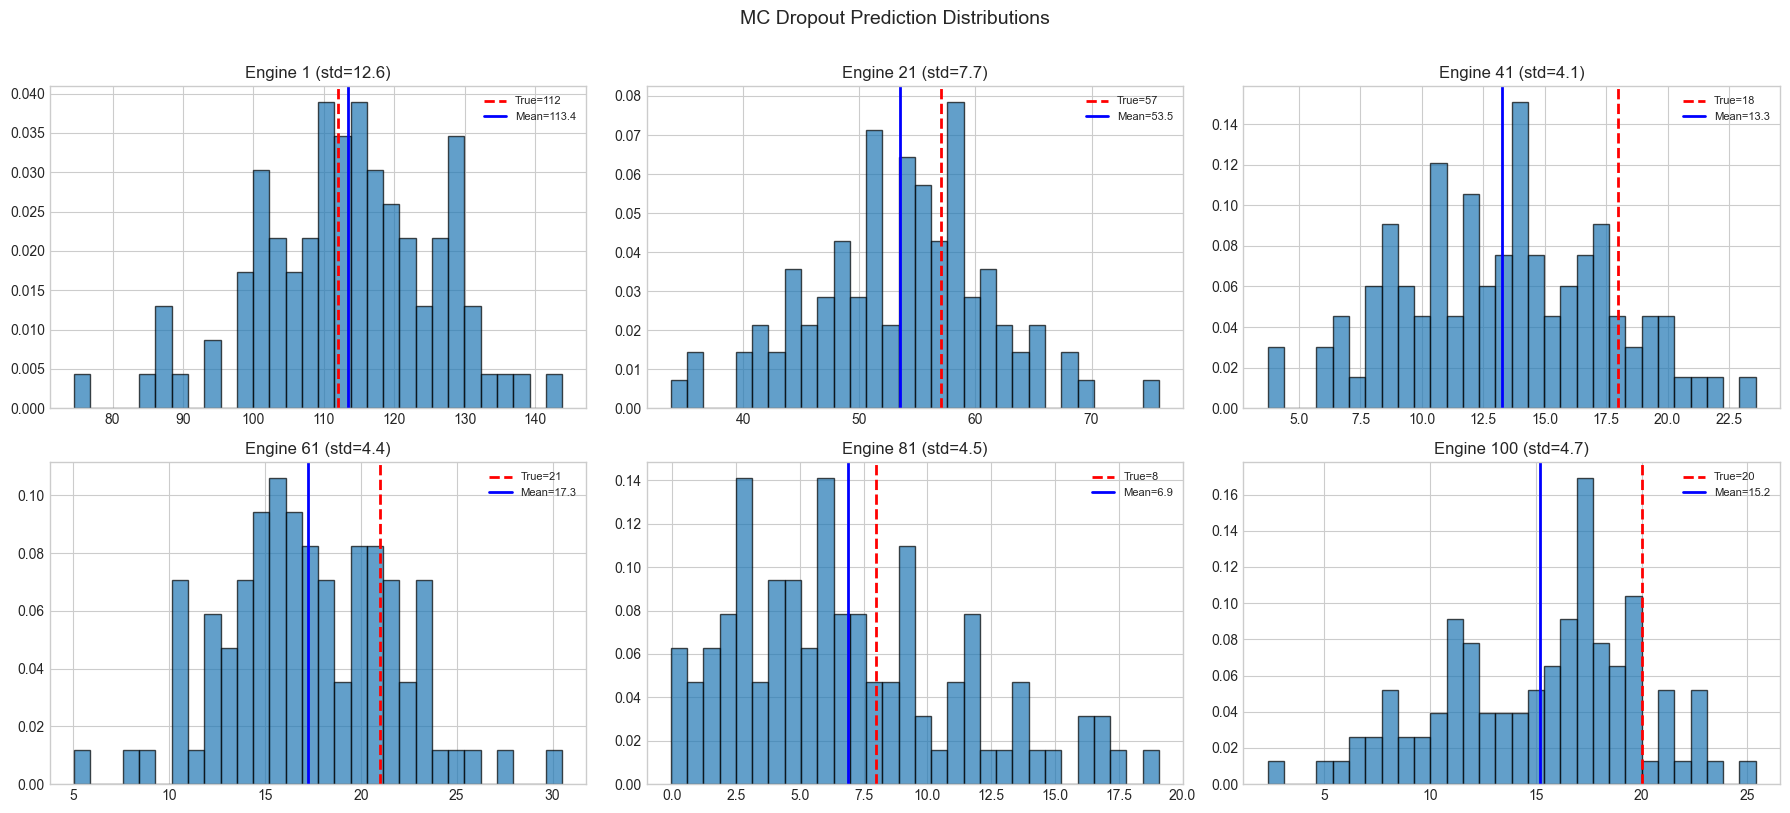

In [18]:
# MC prediction distribution for individual engines
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
sample_engines = [0, 20, 40, 60, 80, 99]

for idx, eng_idx in enumerate(sample_engines):
    ax = axes[idx // 3, idx % 3]
    ax.hist(all_preds[:, eng_idx], bins=30, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(rul_true[eng_idx], color='red', linestyle='--', linewidth=2, label=f'True={rul_true[eng_idx]}')
    ax.axvline(mean_pred[eng_idx], color='blue', linestyle='-', linewidth=2, label=f'Mean={mean_pred[eng_idx]:.1f}')
    ax.set_title(f'Engine {eng_idx+1} (std={std_pred[eng_idx]:.1f})')
    ax.legend(fontsize=8)

plt.suptitle('MC Dropout Prediction Distributions', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 4. Summary

| Metric | Value |
|--------|-------|
| MAE | (fill from above) |
| RMSE | (fill from above) |
| NASA Score | (fill from above) |
| Uncertainty-Error Corr | (fill from above) |

**Key takeaways:**
- CNN-Transformer captures temporal patterns effectively
- MC Dropout provides meaningful uncertainty estimates
- Higher uncertainty correlates with higher prediction errors (model knows when it's unsure)